# 🔬 Customer Churn — Correlation Analysis → v4 Feature Selection
**Kaggle Playground Series 2026**

Purpose: identify correlated feature groups and select one representative per group.
Output: cleaned feature list for modelling v4.

### Structure
1. Setup & Load
2. Correlation heatmap — full 40 features
3. Correlation groups — identify redundant pairs
4. Within-group analysis — which feature to keep
5. v4 feature list

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pointbiserialr

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv").drop(columns=['risk_score'], errors='ignore')
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"Features: {X_train.columns.tolist()}")


X_train : (594194, 40)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'payment_type', 'pm_bank_transfer', 'pm_credit_card', 'pm_electronic_check', 'pm_mailed_check', 'has_internet', 'is_fiber', 'num_protective_addons', 'has_any_protection', 'internet_no_protection', 'num_streaming_addons', 'num_total_addons', 'is_new_customer', 'is_early', 'is_long_term', 'contract_x_tenure', 'avg_monthly_charge', 'charge_per_addon', 'sticker_shock', 'charge_x_fiber', 'is_solo', 'has_family']


---
## 2. Correlation Heatmap — Full 40 Features

Pearson correlation between all feature pairs.
High correlation (|r| > 0.7) = likely redundant pair.

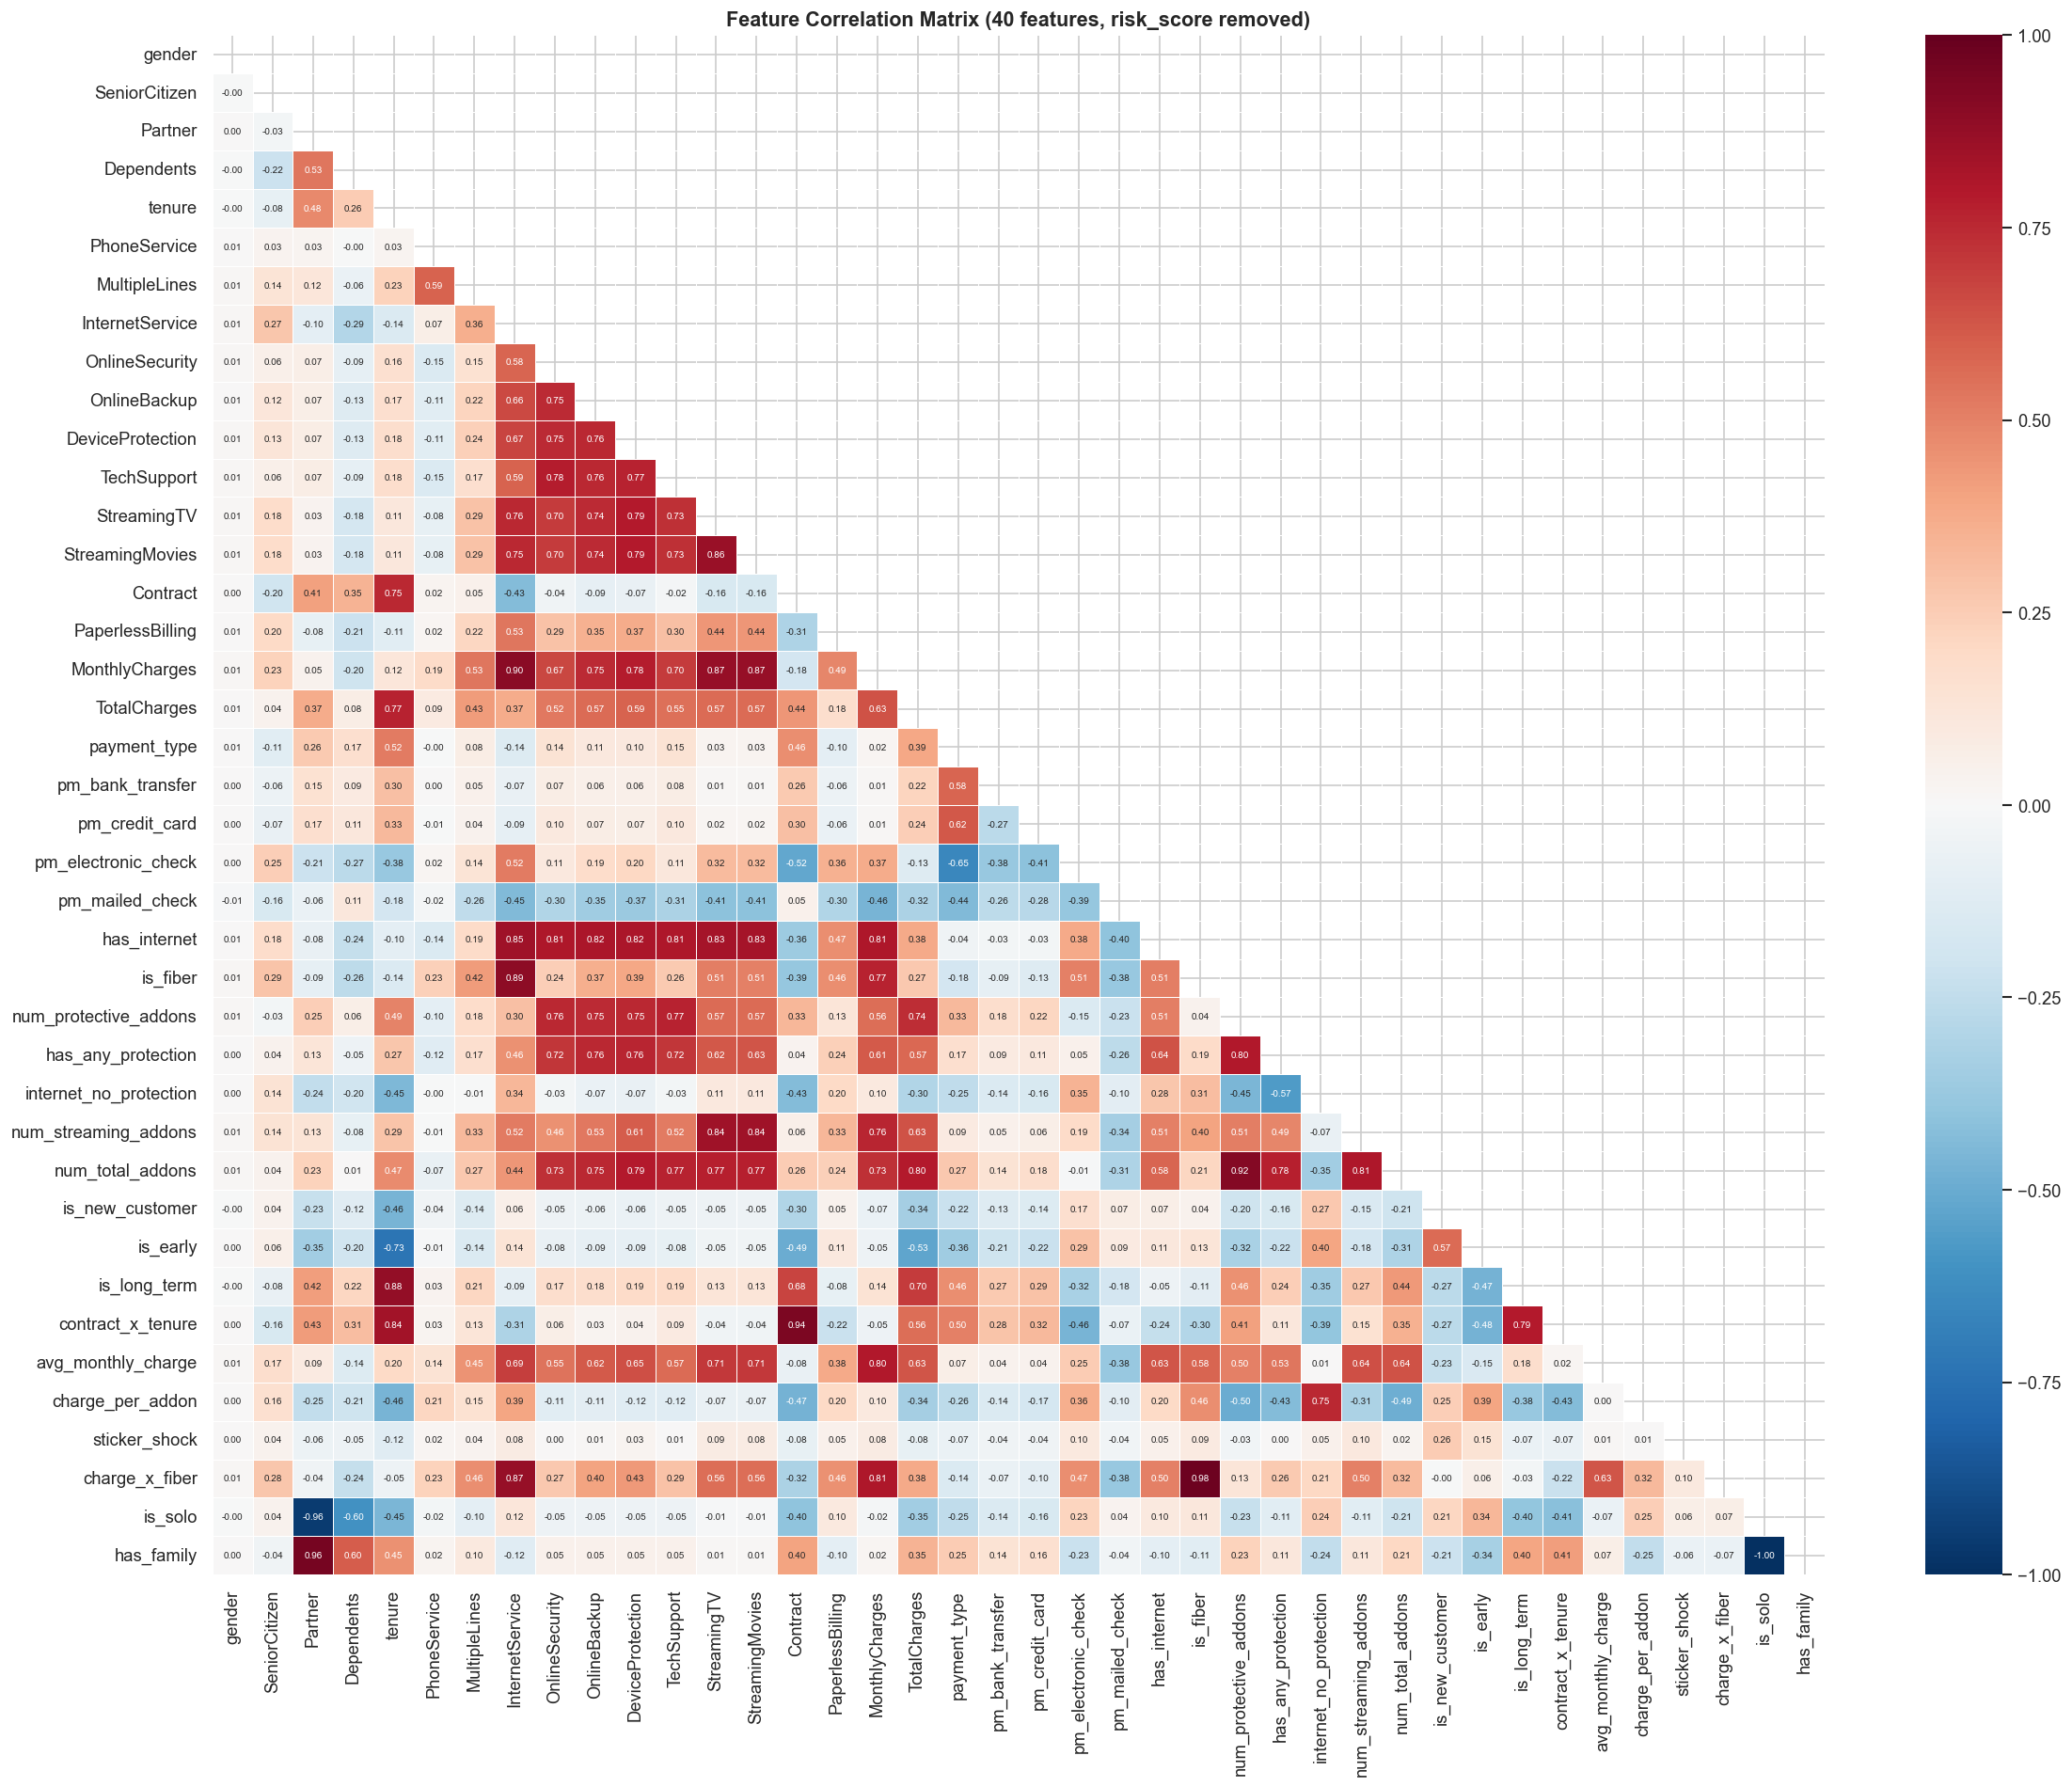

Highly correlated pairs (|r| > 0.70):

             feature_a             feature_b      r
               is_solo            has_family -1.000
              is_fiber        charge_x_fiber  0.981
               Partner            has_family  0.955
               Partner               is_solo -0.955
              Contract     contract_x_tenure  0.939
 num_protective_addons      num_total_addons  0.921
       InternetService        MonthlyCharges  0.903
       InternetService              is_fiber  0.891
                tenure          is_long_term  0.878
       InternetService        charge_x_fiber  0.874
           StreamingTV        MonthlyCharges  0.871
       StreamingMovies        MonthlyCharges  0.870
           StreamingTV       StreamingMovies  0.865
       InternetService          has_internet  0.847
           StreamingTV  num_streaming_addons  0.845
       StreamingMovies  num_streaming_addons  0.844
                tenure     contract_x_tenure  0.840
       StreamingMovies   

In [2]:
corr = X_train.corr()

# ── Full heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 6}
)
ax.set_title('Feature Correlation Matrix (40 features, risk_score removed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── High correlation pairs (|r| > 0.7) ────────────────────────────────────
print("Highly correlated pairs (|r| > 0.70):\n")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            high_corr.append({
                'feature_a': corr.columns[i],
                'feature_b': corr.columns[j],
                'r': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('r', key=abs, ascending=False)
print(high_corr_df.to_string(index=False))


---
## 3. Correlation Groups

For each group: which feature has the highest individual correlation with Churn?
That's the one worth keeping — the others are redundant.

Individual feature correlation with Churn (|r|):

               feature  corr_with_churn
   pm_electronic_check           0.4763
              Contract           0.4493
              is_fiber           0.4188
                tenure           0.4185
       InternetService           0.4084
     contract_x_tenure           0.4009
              is_early           0.3783
        charge_x_fiber           0.3749
internet_no_protection           0.3576
      charge_per_addon           0.3489
          is_long_term           0.3307
          payment_type           0.3160
      PaperlessBilling           0.2851
          has_internet           0.2813
       is_new_customer           0.2802
        MonthlyCharges           0.2730
            Dependents           0.2404
         SeniorCitizen           0.2364
            has_family           0.2361
               is_solo           0.2361
               Partner           0.2282
           StreamingTV           0.2262
       StreamingMovies        

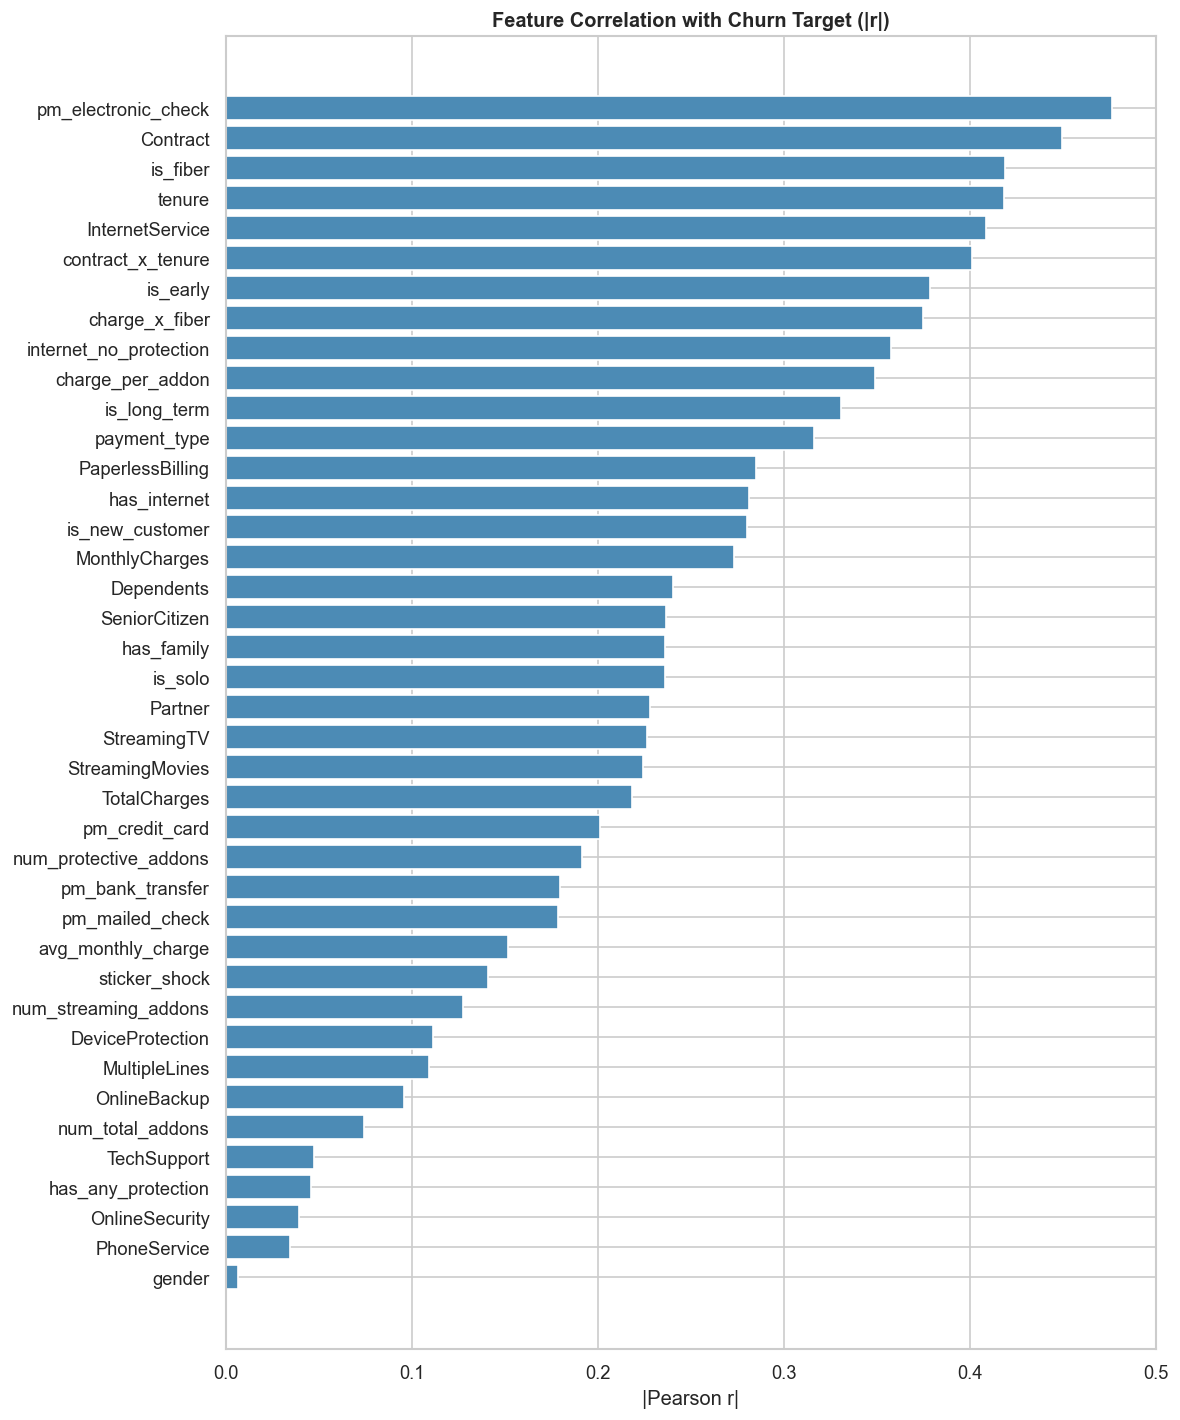

In [3]:
# ── Individual correlation with target ────────────────────────────────────
target_corr = (
    X_train.corrwith(y_train)
    .abs()
    .sort_values(ascending=False)
    .rename('corr_with_churn')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
target_corr['corr_with_churn'] = target_corr['corr_with_churn'].round(4)

print("Individual feature correlation with Churn (|r|):\n")
print(target_corr.to_string(index=False))

# ── Visualise ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(
    target_corr['feature'][::-1],
    target_corr['corr_with_churn'][::-1],
    color='#4C8BB5', edgecolor='white'
)
ax.set_title('Feature Correlation with Churn Target (|r|)', fontweight='bold')
ax.set_xlabel('|Pearson r|')
plt.tight_layout()
plt.show()


---
## 4. Within-Group Analysis

For each correlated group, compare: correlation with target, gain importance from v3,
and interpretability. Keep the best representative.

In [4]:
# Paste v3 gain importance here for reference
v3_gain = {
    'Contract'              : 32.46,
    'contract_x_tenure'     : 18.04,
    'tenure'                :  8.74,
    'InternetService'       :  8.39,
    'pm_electronic_check'   :  6.99,
    'charge_per_addon'      :  4.96,
    'charge_x_fiber'        :  4.55,
    'TotalCharges'          :  2.56,
    'avg_monthly_charge'    :  2.00,
    'MonthlyCharges'        :  1.86,
    'is_fiber'              :  1.76,
    'num_streaming_addons'  :  1.18,
    'PaperlessBilling'      :  0.97,
    'is_early'              :  0.80,
    'SeniorCitizen'         :  0.62,
    'Dependents'            :  0.58,
    'OnlineSecurity'        :  0.57,
    'payment_type'          :  0.51,
    'MultipleLines'         :  0.45,
    'is_new_customer'       :  0.40,
    'PhoneService'          :  0.27,
    'num_protective_addons' :  0.22,
    'internet_no_protection':  0.22,
    'StreamingTV'           :  0.15,
}

# Build comparison table
summary = target_corr.copy()
summary['v3_gain_pct'] = summary['feature'].map(v3_gain).fillna(0.0)

print("Feature summary — correlation with target vs v3 gain importance:\n")
print(summary.sort_values('v3_gain_pct', ascending=False).to_string(index=False))

# ── Group decisions ────────────────────────────────────────────────────────
print("""
Correlation group decisions:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GROUP 1 — Tenure / Contract
  Contract, contract_x_tenure, tenure, is_early, is_new_customer
  → Keep: Contract, contract_x_tenure, tenure
    (contract_x_tenure captures interaction; is_early/is_new are weak buckets)

GROUP 2 — Internet type
  InternetService, is_fiber, has_internet, charge_x_fiber
  → Keep: InternetService, charge_x_fiber
    (is_fiber is fully redundant with InternetService==2; has_internet near zero gain)

GROUP 3 — Charges
  MonthlyCharges, TotalCharges, avg_monthly_charge, charge_per_addon, charge_x_fiber
  → Keep: MonthlyCharges, avg_monthly_charge, charge_per_addon
    (TotalCharges = MonthlyCharges × tenure, already captured by avg_monthly_charge)

GROUP 4 — Add-ons (protective)
  num_protective_addons, has_any_protection, internet_no_protection, OnlineSecurity
  → Keep: OnlineSecurity (strongest individual signal per EDA)
    (has_any_protection near zero gain; internet_no_protection redundant)

GROUP 5 — Demographics
  Partner, Dependents, is_solo, has_family
  → Keep: is_solo
    (combines both; has_family is its mirror image — perfectly correlated)
"""
)


Feature summary — correlation with target vs v3 gain importance:

               feature  corr_with_churn  v3_gain_pct
              Contract           0.4493        32.46
     contract_x_tenure           0.4009        18.04
                tenure           0.4185         8.74
       InternetService           0.4084         8.39
   pm_electronic_check           0.4763         6.99
      charge_per_addon           0.3489         4.96
        charge_x_fiber           0.3749         4.55
          TotalCharges           0.2184         2.56
    avg_monthly_charge           0.1517         2.00
        MonthlyCharges           0.2730         1.86
              is_fiber           0.4188         1.76
  num_streaming_addons           0.1274         1.18
      PaperlessBilling           0.2851         0.97
              is_early           0.3783         0.80
         SeniorCitizen           0.2364         0.62
            Dependents           0.2404         0.58
        OnlineSecurity           

---
## 5. v4 Feature List

Final clean set — one representative per correlated group, weak features removed.

In [5]:
V4_FEATURES = [
    # Tenure & contract
    'Contract',
    'contract_x_tenure',
    'tenure',

    # Internet
    'InternetService',
    'charge_x_fiber',

    # Charges
    'MonthlyCharges',
    'avg_monthly_charge',
    'charge_per_addon',

    # Payment
    'pm_electronic_check',
    'PaperlessBilling',
    'payment_type',

    # Add-ons
    'OnlineSecurity',
    'num_streaming_addons',
    'TechSupport',

    # Demographics
    'SeniorCitizen',
    'is_solo',
    'Dependents',

    # Remaining with some signal
    'MultipleLines',
    'num_protective_addons',
]

print(f"v4 feature count: {len(V4_FEATURES)}")
print()

# Verify all features exist in X_train
missing = [f for f in V4_FEATURES if f not in X_train.columns]
print(f"Missing features: {missing if missing else 'None ✅'}")
print()

# Quick correlation check within v4 set
v4_corr = X_train[V4_FEATURES].corr()
remaining_high = []
for i in range(len(v4_corr.columns)):
    for j in range(i+1, len(v4_corr.columns)):
        r = v4_corr.iloc[i, j]
        if abs(r) > 0.70:
            remaining_high.append({
                'feature_a': v4_corr.columns[i],
                'feature_b': v4_corr.columns[j],
                'r': round(r, 3)
            })

if remaining_high:
    print("Still correlated pairs in v4 set (|r| > 0.70):")
    print(pd.DataFrame(remaining_high).to_string(index=False))
else:
    print("No pairs with |r| > 0.70 remaining ✅")

print()
print("Save this list — use V4_FEATURES in churn_modelling_v4.ipynb")


v4 feature count: 19

Missing features: None ✅

Still correlated pairs in v4 set (|r| > 0.70):
        feature_a             feature_b     r
         Contract     contract_x_tenure 0.939
         Contract                tenure 0.754
contract_x_tenure                tenure 0.840
  InternetService        charge_x_fiber 0.874
  InternetService        MonthlyCharges 0.903
   charge_x_fiber        MonthlyCharges 0.810
   MonthlyCharges    avg_monthly_charge 0.803
   MonthlyCharges  num_streaming_addons 0.759
   OnlineSecurity           TechSupport 0.783
   OnlineSecurity num_protective_addons 0.756
      TechSupport num_protective_addons 0.773

Save this list — use V4_FEATURES in churn_modelling_v4.ipynb
